# Loan Data Analysis using Python

#### This project analyzes loan application data to understand the key factors that influence loan approval decisions. The analysis focuses on exploring applicant income, loan amount, credit history, and other attributes to identify meaningful patterns in the dataset.

## 1. Introduction

#### Financial institutions receive thousands of loan applications. Understanding the factors that influence loan approval can help improve decision-making and risk assessment.

#### In this project, we perform **Exploratory Data Analysis (EDA)** on a loan dataset to identify trends and relationships between applicant characteristics and loan approval status.

## 3. Business Problem / Questions

#### Financial institutions need to evaluate loan applications carefully to minimize risk while approving loans for eligible applicants. Understanding the key factors that influence loan approval decisions can help improve the efficiency and fairness of the approval process.

#### This analysis aims to answer the following business questions:

##### 1. What is the overall loan approval rate among applicants?
##### 2. Does an applicant's credit history influence loan approval?
##### 3. How does applicant income affect loan approval decisions?
##### 4. Does the requested loan amount impact approval rates?
##### 5. Are there differences in loan approvals based on property area (Urban, Semiurban, Rural)?

## 2. Import Libraries
#### We begin by importing the Python libraries required for data analysis and visualization.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

#### The dataset contains information about loan applicants such as income, loan amount, credit history, and property area.

In [34]:
df = pd.read_csv(r"C:\Users\Priyanka\Desktop\loan-data-analysis\data\loan_data.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 4. Data Overview

#### Before performing analysis, we explore the dataset to understand its structure, data types, and missing values.

In [8]:
# View dataset
df.head()

# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
# Missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 5. Data Cleaning

#### Handling missing values is an important step before performing analysis.

In [11]:
# Fill missing values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 6. Exploratory Data Analysis

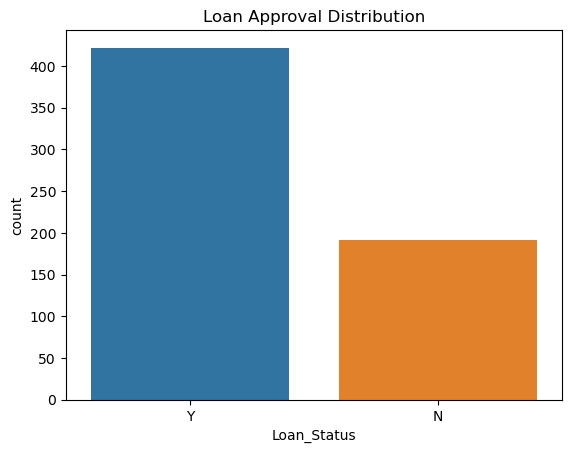

In [41]:
# Loan approval distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.savefig(r"C:\Users\Priyanka\Desktop\loan-data-analysis\images\loan_approval_distribution.png", bbox_inches="tight")
plt.show()

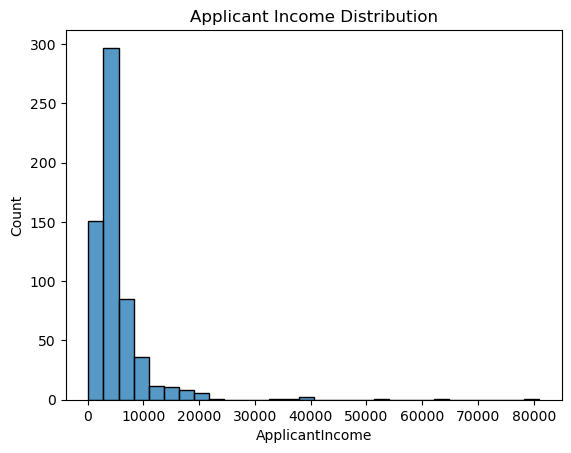

In [42]:
# Income distribution
sns.histplot(df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.savefig(r"C:\Users\Priyanka\Desktop\loan-data-analysis\images\applicant_income_distribution.png", bbox_inches="tight")
plt.show()

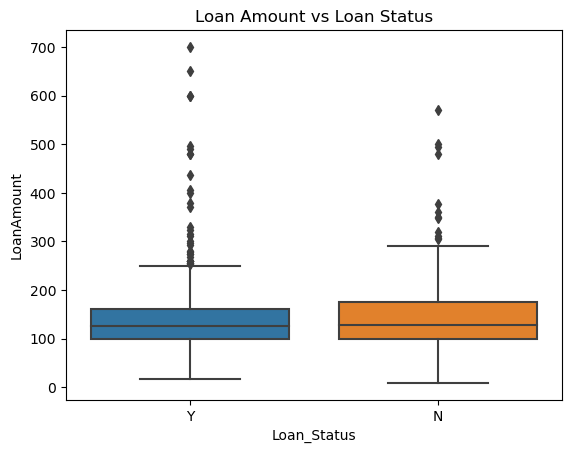

In [43]:
# Loan amount vs approval
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.savefig(r"C:\Users\Priyanka\Desktop\loan-data-analysis\images\loan_amount_VS_loan_status.png", bbox_inches="tight")
plt.show()

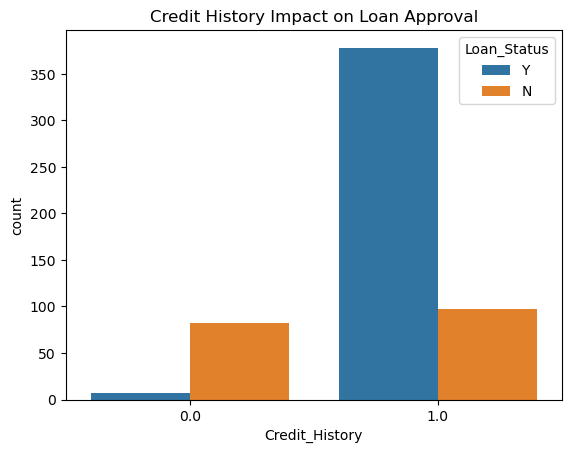

In [44]:
# Credit history vs approval
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History Impact on Loan Approval")
plt.savefig(r"C:\Users\Priyanka\Desktop\loan-data-analysis\images\Credit_history_impact_on_loan_approval.png", bbox_inches="tight")
plt.show()

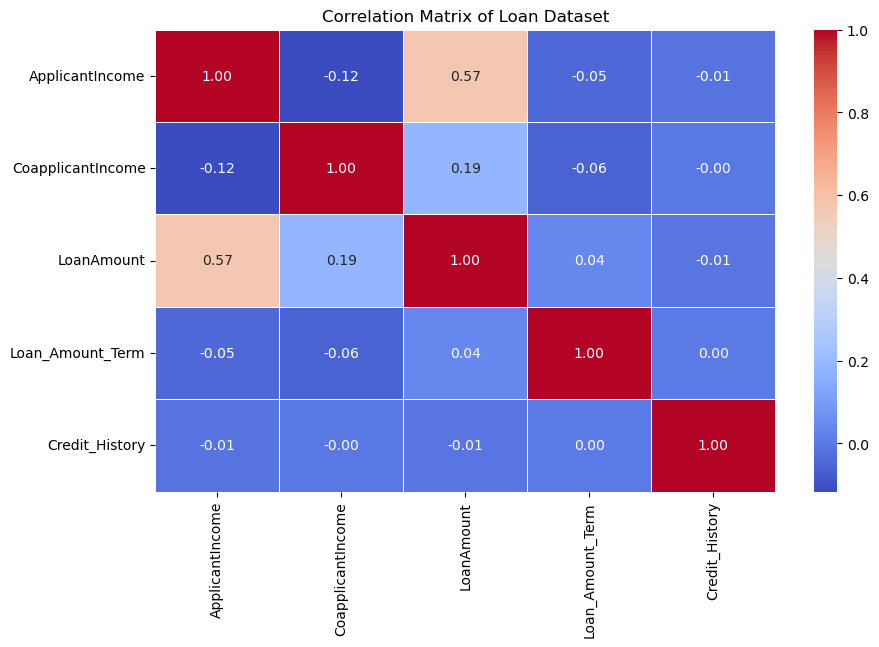

In [45]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix of Loan Dataset")
plt.savefig(r"C:\Users\Priyanka\Desktop\loan-data-analysis\images\Correlation_Matrix.png", bbox_inches="tight")
plt.show()

### Business Question 1: What percentage of loan applications are approved?

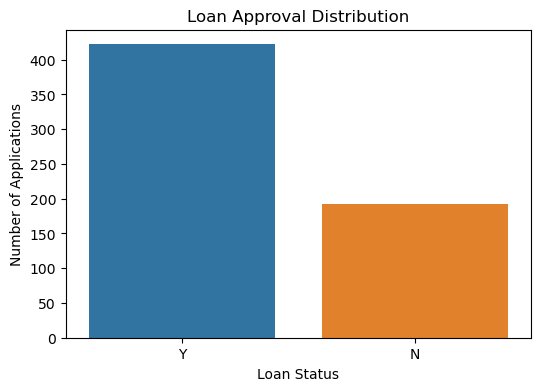

Loan Approval Rate: 68.73 %


In [18]:
loan_status_counts = df['Loan_Status'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

approval_rate = loan_status_counts['Y'] / loan_status_counts.sum() * 100
print("Loan Approval Rate:", round(approval_rate,2), "%")

##### Most applicants receive loan approval, but a significant portion still gets rejected, indicating stricter approval criteria.

### Business Question 2: Does credit history affect loan approval?

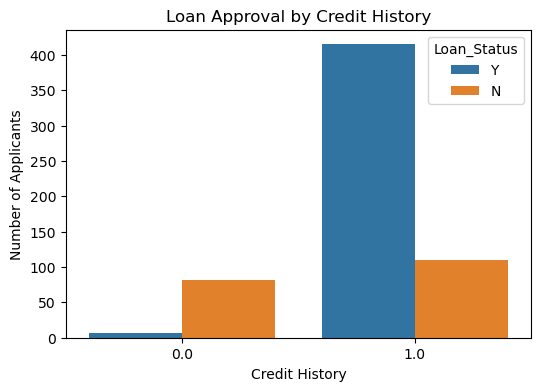

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.show()

##### Applicants with a good credit history have a much higher loan approval rate.

### Business Question 3: How does applicant income vary?

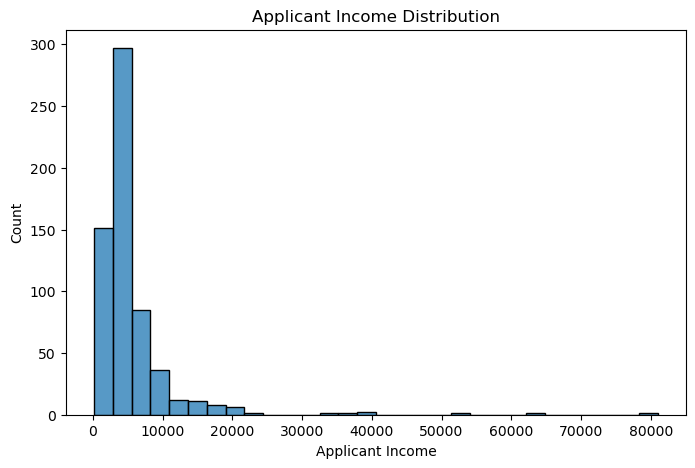

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Applicant Income Distribution")

plt.xlabel("Applicant Income")

plt.show()

##### Most applicants fall within the lower to middle income range.

### Business Question 4: Does loan amount impact approval?

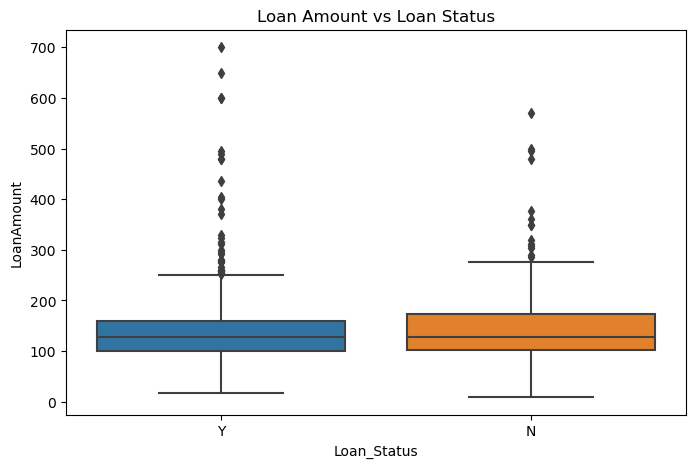

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)

plt.title("Loan Amount vs Loan Status")

plt.show()

##### Higher loan amounts show slightly higher rejection rates.

### Business Question 5: Which property areas have higher approvals?

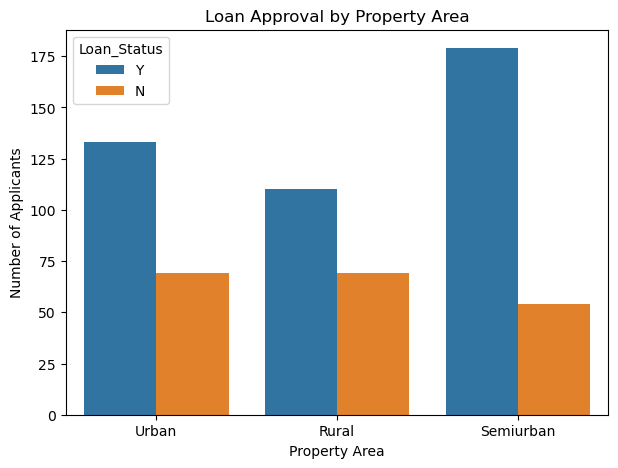

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Loan Approval by Property Area")

plt.xlabel("Property Area")

plt.ylabel("Number of Applicants")

plt.show()

##### Semiurban areas tend to have higher loan approval rates compared to rural areas

## 7. Key Insights

### • Credit history is the most important factor influencing loan approval.  
### • Semiurban areas show higher loan approval rates.  
### • Income alone does not guarantee loan approval.  
### • Loan amount shows moderate influence on approval decisions.

## 8. Conclusion

### This analysis explored key factors influencing loan approval decisions. Credit history emerged as the most significant predictor of approval, while property area and loan amount also showed notable relationships with approval outcomes.